# Franks Hertz

--- Dados filtrados: U2 <= 30 V ---
Número de pontos original: 2532
Número de pontos após filtrar: 1402

--- Máximos (Picos) Encontrados (Dados Filtrados) ---
      Tensao_U2_V  Sinal_U1_V
532         15.86        0.39
794         20.92        0.74
1216        26.60        1.21

--- Mínimos (Vales) Encontrados (Dados Filtrados) ---
      Tensao_U2_V  Sinal_U1_V
583         16.96        0.38
919         22.88        0.70
1338        27.82        1.18

Gráfico salvo como: franck_hertz_analise_filtrada.png


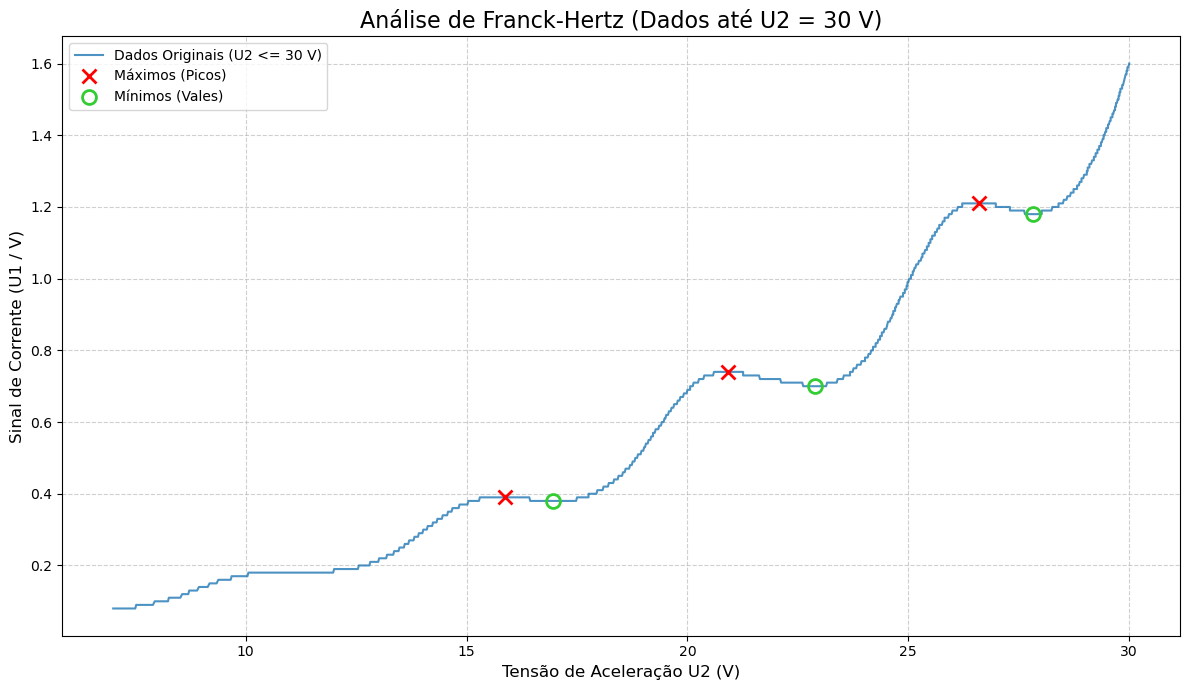

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# O nome do arquivo a ser lido
file_name = 'medida160C_7v_40v_01uv2'

# A codificação 'latin1' foi a que funcionou para o seu arquivo
encoding = 'latin1'
    
df = None
try:
    # Tenta ler o arquivo com as configurações corretas
    df = pd.read_csv(
        file_name,
        sep='\t',        # Separador de tabulação
        decimal=',',     # Decimal separado por vírgula
        header=1,        # O cabeçalho está na segunda linha (índice 1)
        encoding=encoding
    )
except Exception as e:
    print(f"Erro ao ler o arquivo com {encoding}: {e}")

if df is not None:
    try:
        # Renomeia as colunas para facilitar
        df.columns = ['Tensao_U2_V', 'Sinal_U1_V']
        
        # Garante que ambas as colunas sejam numéricas
        df['Tensao_U2_V'] = pd.to_numeric(df['Tensao_U2_V'], errors='coerce')*2
        df['Sinal_U1_V'] = pd.to_numeric(df['Sinal_U1_V'], errors='coerce')
        
        # Remove quaisquer linhas que tenham ficado com NaN
        df = df.dropna()

        # --- FILTRAR OS DADOS ANTES DA ANÁLISE ---
        # Esta é a etapa que você pediu para incluir
        limite_tensao_max = 30
        limite_tensao_min = 7
        tendencia = 0.01
        Filtro_de_dados = df[ df['Tensao_U2_V'] >= limite_tensao_min].copy()
        ##Filtro_de_dados = df[Filtro_de_dados1 <= limite_tensao_max ].copy()
        ##Filtro_de_dados = Filtro_de_dados.dropna()
        print(f"--- Dados filtrados: U2 <= {limite_tensao_max} V ---")
        print(f"Número de pontos original: {len(df)}")
        print(f"Número de pontos após filtrar: {len(Filtro_de_dados)}")
        
        # O DataFrame 'df_filtered' agora contém os dados que serão analisados.
        # Todas as operações subsequentes usarão este DataFrame filtrado.

        if Filtro_de_dados.empty:
            print("O DataFrame está vazio após a filtragem.")
        else:
            # Define os eixos X (Tensão) e Y (Sinal/Corrente) USANDO OS DADOS FILTRADOS
            X = Filtro_de_dados['Tensao_U2_V']
            Y = Filtro_de_dados['Sinal_U1_V']

            # --- Encontrar Máximos (Picos) ---
            # A análise agora é feita APENAS no 'df_filtered'
            pontos_de_maximo, _ = find_peaks(Y, prominence=tendencia , distance=100)
            
            # --- Encontrar Mínimos (Vales) ---
            pontos_de_minimo, _ = find_peaks(-Y, prominence=tendencia, distance=100)

            # Imprime as tabelas de resultados
            print("\n--- Máximos (Picos) Encontrados (Dados Filtrados) ---")
            maximos = Filtro_de_dados.iloc[pontos_de_maximo]
            print(maximos.to_string()) 

            print("\n--- Mínimos (Vales) Encontrados (Dados Filtrados) ---")
            minimos = Filtro_de_dados.iloc[pontos_de_minimo]
            print(minimos.to_string())

            # --- Gerar o Gráfico ---
            plt.figure(figsize=(12, 7))
            
            # Plotar os dados filtrados
            plt.plot(X, Y, label=f'Dados Originais (U2 <= {limite_tensao_max} V)', alpha=0.8)
            
            # Marcar os máximos no gráfico
            plt.plot(
                X.iloc[pontos_de_maximo], 
                Y.iloc[pontos_de_maximo], 
                'x', 
                color='red', 
                markersize=10,
                mew=2,
                label='Máximos (Picos)'
            )
            
            # Marcar os mínimos no gráfico
            plt.plot(
                X.iloc[pontos_de_minimo], 
                Y.iloc[pontos_de_minimo], 
                'o', 
                color='limegreen', 
                markerfacecolor='none',
                markersize=10,
                mew=2,
                label='Mínimos (Vales)'
            )
            
            # Adicionar legendas e títulos
            plt.title(f'Análise de Franck-Hertz (Dados até U2 = {limite_tensao_max} V)', fontsize=16)
            plt.xlabel('Tensão de Aceleração U2 (V)', fontsize=12)
            plt.ylabel('Sinal de Corrente (U1 / V)', fontsize=12)
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.tight_layout()
            
            # Salvar o arquivo de imagem
            plot_filename = 'franck_hertz_analise_filtrada.png'
            plt.savefig(plot_filename)
            print(f"\nGráfico salvo como: {plot_filename}")

    except Exception as e:
        print(f"Ocorreu um erro durante a análise ou plotagem: {e}")
else:

    print("A leitura do arquivo falhou, a análise não pode continuar.")

In [59]:
picos = X.iloc[pontos_de_maximo].values
vales = X.iloc[pontos_de_minimo].values
# Print values for maximum points
print("Voltage values at maxima:")
print(picos)

# If you want to print minimum points as well:
print("\nVoltage values at minima:")
print(vales)

medias = (picos + vales)/2

print("\nVoltage values at medias:")
print(medias)
print("")

for i in range(len(medias)-1):  # Changed range to avoid going out of bounds
    print(f"Diferença entre picos {i+1} e {i}: {medias[i+1] - medias[i]:.2f} V")
    


Voltage values at maxima:
[15.86 20.92 26.6 ]

Voltage values at minima:
[16.96 22.88 27.82]

Voltage values at medias:
[16.41 21.9  27.21]

Diferença entre picos 1 e 0: 5.49 V
Diferença entre picos 2 e 1: 5.31 V
